In [2]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_regression
import matplotlib.pyplot as plt
from sklearn.preprocessing import PowerTransformer
from sklearn.model_selection import train_test_split

In [6]:
df = pd.read_csv('C:\\MACHINE LEARNING\\data\\nyc_housing_base.csv')

In [14]:
df.dropna(inplace= True)

In [15]:
q1 = df['sale_price'].quantile(0.25)
q3 = df['sale_price'].quantile(0.75)

iqr = q3 - q1

upper = q3 + 1.5 * iqr
lower = q1 - 1.5 * iqr

df = df[(df["sale_price"] < upper) & (df['sale_price'] > lower)]

In [16]:
df['Price_cat'] = pd.qcut(df['sale_price'], q = 10, labels= [1,2,3, 4, 5, 6, 7, 8, 9, 10])

In [17]:
df_cat = df.select_dtypes(include= 'str').columns

df = pd.get_dummies(df, columns= df_cat)

In [18]:
train, temp = train_test_split(df, test_size= 0.2, stratify= df['Price_cat'], random_state= 42)
val, test = train_test_split(temp, test_size= 0.5, stratify= temp['Price_cat'], random_state= 42)

In [19]:
del train['Price_cat']
del test['Price_cat']
del val['Price_cat']

In [20]:
x_train = train.drop('sale_price', axis = 1)
y_train = train['sale_price']

x_val = val.drop('sale_price', axis = 1)
y_val = val['sale_price']

x_test = test.drop('sale_price', axis = 1)
y_test = test['sale_price']

In [21]:
selector = SelectKBest(score_func= f_regression, k = 100)
selector.fit(x_train, y_train)

x_train_s = selector.transform(x_train)
x_val_s = selector.transform(x_val)
x_test_s = selector.transform(x_test)

In [22]:
transform = PowerTransformer(method = 'box-cox')

y_train_s = transform.fit_transform(y_train.to_frame())
y_val_s = transform.transform(y_val.to_frame())
y_test_s = transform.transform(y_test.to_frame())

In [23]:
model = XGBRegressor(n_estimators = 1500, learning_rate = 0.006, max_depth = 7)
model.fit(x_train_s, y_train_s)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [24]:
pred_train = model.predict(x_train_s)
pred_val = model.predict(x_val_s)

pred_train = transform.inverse_transform(pred_train.reshape(-1, 1))
pred_val = transform.inverse_transform(pred_val.reshape(-1, 1))

In [25]:
mae_train = mean_absolute_error(y_train, pred_train)
print ("TRAIN ERROR:%.2f"%mae_train)

mae_val = mean_absolute_error(y_val, pred_val)
print ("VAL ERROR:%.2f"%mae_val)


print ('MEAN OF PRICE:',df['sale_price'].mean())

TRAIN ERROR:197515.44
VAL ERROR:218236.03
MEAN OF PRICE: 810329.3668654738


(array([ 125.,  260., 1218., 2912., 3293., 5040., 5116., 2916., 2035.,
        1229.]),
 array([-3.10301191, -2.56936259, -2.03571327, -1.50206395, -0.96841463,
        -0.43476531,  0.09888401,  0.63253333,  1.16618265,  1.69983197,
         2.23348129]),
 <BarContainer object of 10 artists>)

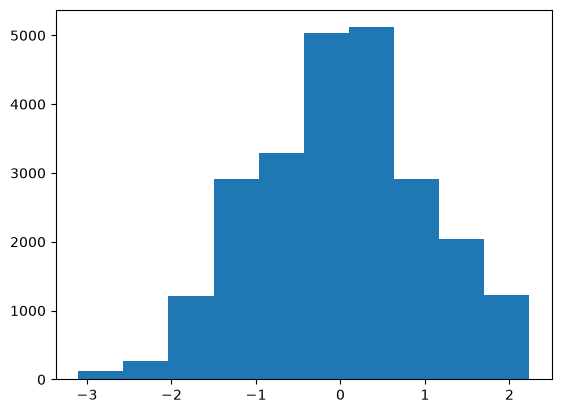

In [26]:
plt.hist(y_train_s)